The traffic Sign Classification dataset is used to train the model of the traffic signs in Keras.

In [1]:
import os
import pathlib
import random
import numpy as np
import matplotlib.pyplot as plt

import zipfile
import requests
import glob as glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.utils import image_dataset_from_directory

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from dataclasses import dataclass

from zipfile import ZipFile
from urllib.request import urlretrieve

from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Activation
from keras.datasets.mnist import load_data

import json
import shutil
import cv2
import pandas as pd
from matplotlib import pyplot as plt

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [2]:
SEED_VALUE = 41

# Fix seed to make training deterministic.
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

The Traffic Sign dataset is a Kaggle dataset and the path is specified as "/root/.kaggle".

In [3]:
KAGGLE_PATH = "/root/.kaggle"
if os.path.exists(KAGGLE_PATH):
  !rm -r "$KAGGLE_PATH"

!mkdir "$KAGGLE_PATH"
!touch "$KAGGLE_PATH/kaggle.json"

# https://www.kaggle.com/
api_token = {"username":"Colab_Keras","key":"KGAT_6c5e3427714f0b3f5fe56de3de7aa623"}

with open(KAGGLE_PATH+'/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("ahemateja19bec1025/traffic-sign-dataset-classification")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'traffic-sign-dataset-classification' dataset.
Path to dataset files: /kaggle/input/traffic-sign-dataset-classification


The dataclass module is used to split the train and test parameters/images and fine tune the VGG-16 model.

In [21]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 58 # Updated from 43 to 58
    IMG_HEIGHT:  int = 224
    IMG_WIDTH:   int = 224
    CHANNELS:    int = 3

    # The actual training and validation content are directly under 'traffic_Data/DATA' as class folders
    TRAIN_VALID_DATA_ROOT: str = os.path.join(dataset_path, "traffic_Data", "DATA")

    # The test set is structured differently
    DATA_ROOT_TEST:   str = os.path.join(dataset_path, "traffic_Data", "TEST")
    DATA_TEST_GT:     str = os.path.join(dataset_path, "traffic_Data", "Labels.csv")


@dataclass(frozen=True)
class TrainingConfig:
    BATCH_SIZE:       int   = 32
    EPOCHS:           int   = 5
    LEARNING_RATE:    float = 0.0001
    DROPOUT:          float = 0.6
    LAYERS_FINE_TUNE: int   = 8

Create Train and Validation Datasets

Here we use image_dataset_from_directory(), a very convenient utility in Keras for creating an image dataset. The expected file structure for a dataset is shown below, where the images for each class are contained in a separate class sub-folder.

main_directory/
    class_a/
        a_image_1.png
        a_image_2.png
    class_b/
        b_image_1.png
        b_image_2.png
The function is documented here. It has only one required argument, which is the top-level folder for the dataset, but there are several optional arguments that can be used to configure the dataset. We highlight a few even though we are using the default values for some of them. Among them, we have the option for how to specify the label encoding. Here we decided to use integer encoding, which is the default (label_mode='int'), rather than one-hot label encoding. Either option can be used, but there is additional code further below in this implementation that assumes integer encoding.

In [22]:
train_dataset = image_dataset_from_directory(directory=DatasetConfig.TRAIN_VALID_DATA_ROOT,
                                             validation_split=0.2, # Using 20% of data for validation
                                             subset="training",
                                             seed=SEED_VALUE,
                                             batch_size=TrainingConfig.BATCH_SIZE,
                                             shuffle=True,
                                             label_mode='int',
                                             image_size=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
                                            )

valid_dataset = image_dataset_from_directory(directory=DatasetConfig.TRAIN_VALID_DATA_ROOT,
                                             validation_split=0.2, # Using 20% of data for validation
                                             subset="validation",
                                             seed=SEED_VALUE,
                                             batch_size=TrainingConfig.BATCH_SIZE,
                                             shuffle=True,
                                             label_mode='int',
                                             image_size=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
                                            )

Found 4170 files belonging to 58 classes.
Using 3336 files for training.
Found 4170 files belonging to 58 classes.
Using 834 files for validation.


Create a summary of the ase model.

In [23]:
IMG_SHAPE = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH, DatasetConfig.CHANNELS)

# Using pre-trained weights of VGG16
base_model = tf.keras.applications.VGG16(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Display the class names from the training dataset.
print(train_dataset.class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '6', '7', '8', '9']


Display Sample Images from Training Dataset


It's always a good idea to visually inspect some of the images from the dataset. As you can see below, the image quality varies significantly.

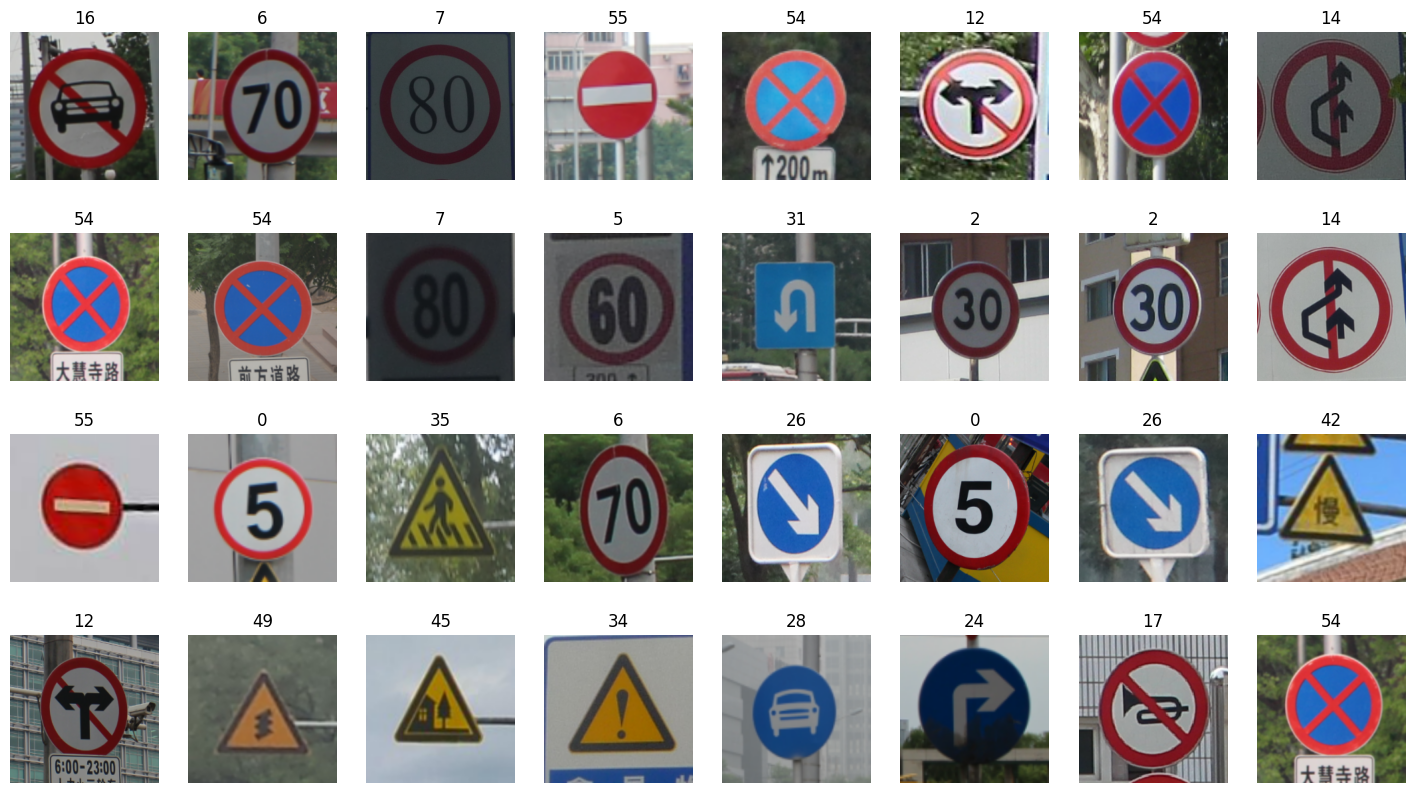

In [26]:
class_names = train_dataset.class_names

plt.figure(figsize=(18, 10))

# Assumes dataset batch_size is at least 32.
num_rows = 4
num_cols = 8

# Here we use the take() method to retrieve just the first batch of data from the training portion of the dataset.
for image_batch, labels_batch in train_dataset.take(1):
    # Plot each of the images in the batch and the associated ground truth labels.
    for i in range(num_rows * num_cols):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        truth_idx = labels_batch[i].numpy()
        plt.title(class_names[truth_idx])
        plt.axis("off")

Create the Test Dataset

It was easy to create the training and validation datasets using image_dataset_from_directory(). However, since the images and labels for the Test dataset are stored separately on the filesystem, we'll need to write some custom code to read and load this data. To create the test dataset, we will need to load the images and the labels in memory and combine them to create a (tf.data.Dataset) test dataset. Four steps are required:

1. Retrieve the class labels from the provided csv file and store them in memory as a Python list
2. Build a list of the image file paths in memory as a Python list
3. Combine the image paths and associated labels in a tf.data.Dataset object
4. Use the dataset object map method to the load and preprocess the images in the dataset

In [27]:
import pandas as pd
import os

# The Test.csv file was not found at the location specified in DatasetConfig.DATA_TEST_GT.
# Based on the file listing, 'labels.csv' is available directly under dataset_path.
# Assuming 'labels.csv' contains the ground truth for the test set.
input_file = os.path.join(dataset_path, "labels.csv")

dataset_df = pd.read_csv(input_file)
# The original code expected a 'ClassId' column, and labels.csv indeed has this structure.
# Removed the incorrect column selection using `cols` variable.
ground_truth_ids = dataset_df["ClassId"].values.tolist()
print("Total number of Test labels: ", len(ground_truth_ids))
print(ground_truth_ids[0:10])

Total number of Test labels:  58
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [28]:
# For referenece, let's print the class names from the train/valid datasets again.
print(train_dataset.class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '6', '7', '8', '9']


Map Ground Truth Class IDs to IDs in Train/Valid Datasets


To create a test dataset that is consistent with the label IDs in the training and validation datasets we need to build a dictionary mapping ground truth IDs in the test dataset to class name IDs. This will ensure that the ground truth labels in the test dataset are correctly interpreted by the model.

Note: This step is not normally required but is an artifact of the way the class names were inferred from the class folder names. An alternative solution would be to use the class_names argument in image_dataset_from_directory(), in which we explicitly specify the order of the class names to be in numerical order.

In [29]:
# Convert train/valid class names to integers.
class_names_int = list(map(int, train_dataset.class_names))

# Create a dictionary mapping ground truth IDs to class name IDs.
gtid_2_cnidx = dict(zip(class_names_int, range(0, DatasetConfig.NUM_CLASSES)))

gtid_2_cnidx.items()

dict_items([(0, 0), (1, 1), (10, 2), (11, 3), (12, 4), (13, 5), (14, 6), (15, 7), (16, 8), (17, 9), (18, 10), (19, 11), (2, 12), (20, 13), (21, 14), (22, 15), (23, 16), (24, 17), (25, 18), (26, 19), (27, 20), (28, 21), (29, 22), (3, 23), (30, 24), (31, 25), (32, 26), (33, 27), (34, 28), (35, 29), (36, 30), (37, 31), (38, 32), (39, 33), (4, 34), (40, 35), (41, 36), (42, 37), (43, 38), (44, 39), (45, 40), (46, 41), (47, 42), (48, 43), (49, 44), (5, 45), (50, 46), (51, 47), (52, 48), (53, 49), (54, 50), (55, 51), (56, 52), (57, 53), (6, 54), (7, 55), (8, 56), (9, 57)])

Print images path.

In [30]:
import glob

# Construct the path to the test images
test_images_path = os.path.join(DatasetConfig.DATA_ROOT_TEST, "*")

# Get a list of all image file paths in the test directory
test_image_filepaths = glob.glob(test_images_path)

print(f"Total number of test images found: {len(test_image_filepaths)}")
print(f"First 5 test image file paths: {test_image_filepaths[:5]}")

Total number of test images found: 1994
First 5 test image file paths: ['/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/043_0030_j.png', '/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/013_0033.png', '/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/002_1_0001_1_j.png', '/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/039_1_0013_1_j.png', '/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/016_0005_j.png']


In [31]:
# Get all the path names to the Test images (will prune later)
image_paths = sorted(glob.glob(DatasetConfig.DATA_ROOT_TEST + os.sep + "*.png"))

print(len(image_paths))
print("")
# Print the first 5 image paths to confirm.
for idx in range(5):
    print(image_paths[idx])

1994

/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0001_j.png
/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0002_j.png
/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0003_j.png
/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0004_j.png
/kaggle/input/traffic-sign-dataset-classification/traffic_Data/TEST/000_0005_j.png


In [32]:
# Convert the ground truth Class IDs to IDs that correctly map to the same classes
# in the train and validation datasets.

# First, extract the raw class ID from each test image filename.
# Assuming class ID is the first part of the filename (e.g., '043' from '043_0030_j.png')
raw_image_class_ids = []
for image_path in image_paths:
    filename = os.path.basename(image_path)
    class_id_str = filename.split('_')[0]
    raw_image_class_ids.append(int(class_id_str))

# Now, map these raw class IDs to the internal label IDs using gtid_2_cnidx.
label_ids = []
for raw_id in raw_image_class_ids:
    label_ids.append(gtid_2_cnidx[raw_id])

print("Total number of test images: ", len(image_paths))
print("Total number of labels generated for test images: ", len(label_ids))
print("First 10 raw image class IDs: ", raw_image_class_ids[0:10])
print("First 10 new mapped label IDs: ", label_ids[0:10])
print("")
print("Train/Valid dataset class names: ", train_dataset.class_names)

Total number of test images:  1994
Total number of labels generated for test images:  1994
First 10 raw image class IDs:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First 10 new mapped label IDs:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Train/Valid dataset class names:  ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '6', '7', '8', '9']


Combine images and labels to create the Test dataset
We can now use from_tensor_slices() to combine the image paths and image labels in a tf.data.dataset.

In [33]:
test_dataset = tf.data.Dataset.from_tensor_slices((image_paths, label_ids))

Load and Preprocess the Images


We still need to load the dataset into memory and preprocess the images. For this, we define three convenience functions for loading and resizing test images in the code cells below.

In [34]:
def preprocess_image(image):
    # Decode and resize image.
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH])
    return image


def load_and_preprocess_image(path):
    # Read image into memory as a byte string.
    image = tf.io.read_file(path)
    return preprocess_image(image)


def load_and_preprocess_from_path_label(path, label):
    return load_and_preprocess_image(path), label

We load and preprocess the images using the test dataset's map() method to call the functions above. And we also set the batch size of the dataset.

In [35]:
# Apply the functions above to the test dataset.
test_dataset = test_dataset.map(load_and_preprocess_from_path_label)

# Set the batch size for the dataset.
test_dataset = test_dataset.batch(TrainingConfig.BATCH_SIZE)

Display Sample Images from the Test Dataset


To confirm we have properly created the test dataset, we will display the images from the first batch. Even though this is a very small sample size, it's pretty clear the test images have a wide range in image quality, with several images severely under-exposed.

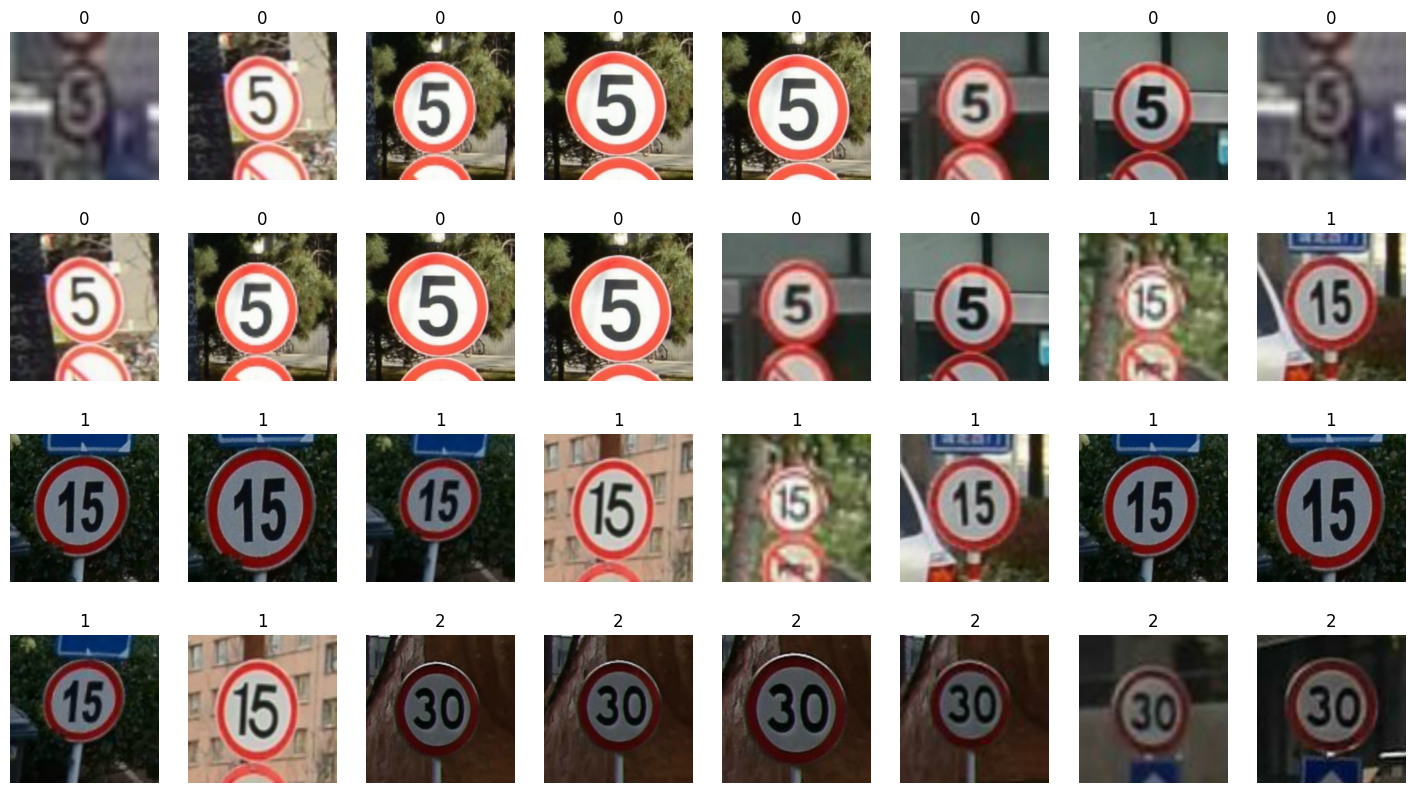

In [36]:
plt.figure(figsize=(18, 10))

# Assumes dataset batch_size is at least 32.
num_rows = 4
num_cols = 8

# Here we use the take() method to retrieve just the first batch of data from the test dataset.
for image_batch, labels_batch in test_dataset.take(1):

    # Plot each of the images in the batch and the associated ground truth labels.
    for i in range(num_rows * num_cols):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        truth_idx = labels_batch[i].numpy()
        plt.title(class_names[truth_idx])
        plt.axis("off")

Modeling VGG-16 (for Fine-Tuning)


The Keras API provides the following utility that is used to instantiate a VGG-16 model. The default settings are shown below for the pre-trained ImageNet model.

Loading the VGG-16 Convolutional Base


We begin by creating a model of the VGG-16 convolutional base. We can do this by instantiating the model and setting include_top = False, which excludes the fully connected layers. We will also instantiate the model with weights that were learned by training the model on the ImageNet dataset weights='imagenet'.

In [37]:
# Specify the model input shape.
input_shape = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH, DatasetConfig.CHANNELS)

print('Loading model with ImageNet weights...')
vgg16_conv_base = tf.keras.applications.vgg16.VGG16(input_shape=input_shape,
                                                    include_top=False, # We will supply our own top.
                                                    weights='imagenet',
                                                   )
vgg16_conv_base.summary()

Loading model with ImageNet weights...


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Freeze the Initial Layers in the Convolutional Base


Now that we have loaded the convolutional base, we need to lock down the initial layers so that only the last few laters (TrainingConfig.LAYERS_FINE_TUNE = 8) are trainable. There are two ways to specify which layers in the model are trainable (tunable).

We can start by making the entire convolutional base trainable by setting the trainable flag to True. Then loop over the initial layers and make them untrainable by setting the same (trainable) flag for each layer to False.

We can freeze the entire convolutional base by setting the trainable flag to False, and then loop over the last few layers and set the trainable flag to True.

We use the first approach in the code cell below. We start by setting the entire convolutional base as "trainable" by setting the trainablee attribute to True.

In [38]:
# Set all layers in the convolutional base to Trainable (will FREEZE initial layers further below).
vgg16_conv_base.trainable = True

# Specify the number of layers to fine tune at the end of the convolutional base.
num_layers_fine_tune = TrainingConfig.LAYERS_FINE_TUNE
num_layers = len(vgg16_conv_base.layers)

# Freeze the initial layers in the convolutional base.
for model_layer in vgg16_conv_base.layers[: num_layers - num_layers_fine_tune]:
    print(f"FREEZING LAYER: {model_layer}")
    model_layer.trainable = False

print("\n")
print(f"Configured to fine tune the last {num_layers_fine_tune} convolutional layers...")
print("\n")

vgg16_conv_base.summary()

FREEZING LAYER: <InputLayer name=input_layer_2, built=True>
FREEZING LAYER: <Conv2D name=block1_conv1, built=True>
FREEZING LAYER: <Conv2D name=block1_conv2, built=True>
FREEZING LAYER: <MaxPooling2D name=block1_pool, built=True>
FREEZING LAYER: <Conv2D name=block2_conv1, built=True>
FREEZING LAYER: <Conv2D name=block2_conv2, built=True>
FREEZING LAYER: <MaxPooling2D name=block2_pool, built=True>
FREEZING LAYER: <Conv2D name=block3_conv1, built=True>
FREEZING LAYER: <Conv2D name=block3_conv2, built=True>
FREEZING LAYER: <Conv2D name=block3_conv3, built=True>
FREEZING LAYER: <MaxPooling2D name=block3_pool, built=True>


Configured to fine tune the last 8 convolutional layers...




Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 12,979,200 (49.51 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

Add the Classifier to Complete the Model

Since we intend to train and use the model to classify traffic signs, we will need to add our own classification layer. The number of dense layers and the number of nodes per layer is a design choice, but the number of nodes in the output layer must match the number of classes in the dataset. Because we are working with a very small dataset, the model will be prone to overfitting, so we have also added a dropout layer in the classifier. The entire model is then assembled as shown below.

In [39]:
inputs = tf.keras.Input(shape=input_shape)

x = tf.keras.applications.vgg16.preprocess_input(inputs)

x = vgg16_conv_base(x)

# Flatten the output from the convolutional base.
x = layers.Flatten()(x)

# Add the classifier.
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(TrainingConfig.DROPOUT)(x)

# Output layer.
outputs = layers.Dense(DatasetConfig.NUM_CLASSES, activation="softmax")(x)

# The final model.
model_vgg16_finetune = keras.Model(inputs, outputs)

model_vgg16_finetune.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  3,211,392 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 58)        │      7,482 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,933,562 (68.41 MB)

 Trainable params: 16,198,074 (61.79 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

Compile and Train the Model


Here we use SparseCategoricalCrossentropy since we are using integer-encoded labels. For one-hot encoded labels, the appropriate loss function would be CategoricalCrossentropy. Since we included a Softmax layer in the model output, we specify from_logits=False. This is the default setting, but it's good practice to be explicit. Alternatively, you can remove the softmax layer in the model and set from_logits=True, and the loss function will apply the softmax function internally. The results should be identical.

In [40]:
# Use this for integer encoded labels.
model_vgg16_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

# Train the Model.
training_results = model_vgg16_finetune.fit(train_dataset,
                                            epochs=TrainingConfig.EPOCHS,
                                            validation_data=valid_dataset,
                                           )

Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4827s 46s/step - accuracy: 0.2497 - loss: 3.3775 - val_accuracy: 0.6859 - val_loss: 1.3479
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4835s 46s/step - accuracy: 0.7422 - loss: 1.0978 - val_accuracy: 0.9101 - val_loss: 0.3561
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4780s 46s/step - accuracy: 0.8789 - loss: 0.4714 - val_accuracy: 0.9748 - val_loss: 0.1245
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4772s 45s/step - accuracy: 0.9302 - loss: 0.2492 - val_accuracy: 0.9868 - val_loss: 0.0497
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4812s 45s/step - accuracy: 0.9562 - loss: 0.1577 - val_accuracy: 0.9928 - val_loss: 0.0334


Plot the Training Results


The convenience function below is used to plot both the training and validation loss and accuracy.

In [41]:
def plot_results(metrics, ylabel=None, ylim=None, metric_name=None, color=None):
    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(ylabel)
    plt.xlim([0, TrainingConfig.EPOCHS - 1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

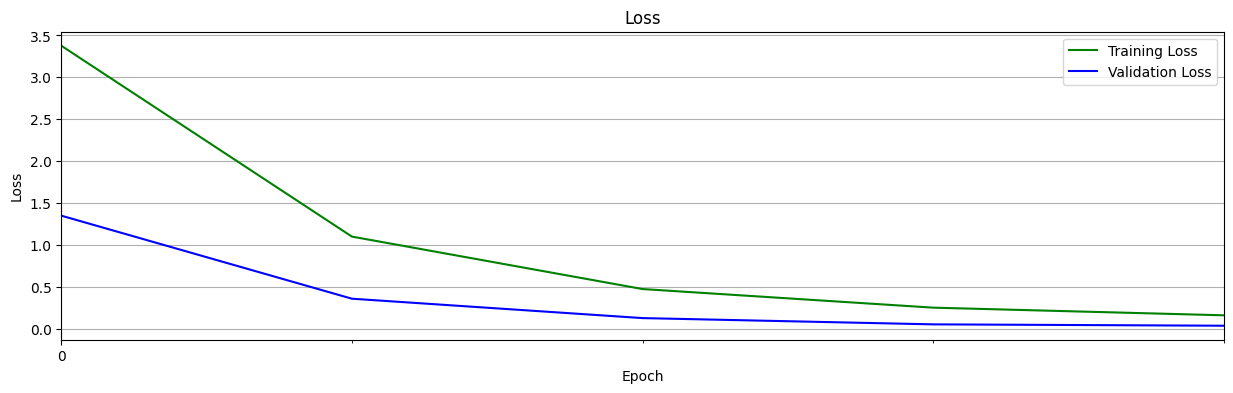

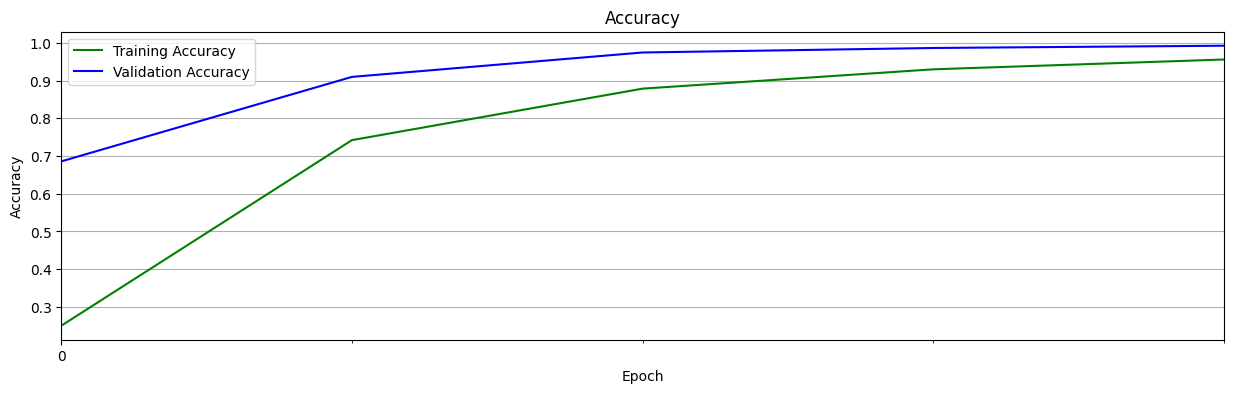

In [42]:
# Retrieve training results.
train_loss = training_results.history["loss"]
train_acc  = training_results.history["accuracy"]
valid_loss = training_results.history["val_loss"]
valid_acc  = training_results.history["val_accuracy"]

plot_results(
    [train_loss, valid_loss],
    ylabel="Loss",
    metric_name=["Training Loss", "Validation Loss"],
    color=["g", "b"],
)

plot_results(
    [train_acc, valid_acc],
    ylabel="Accuracy",
    metric_name=["Training Accuracy", "Validation Accuracy"],
    color=["g", "b"],
)